<a href="https://colab.research.google.com/github/AlvaroAceval16/MachineLearning/blob/main/P1_Regresion_Lineal_Simple_Automobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1. Cargar datos y Librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
# https://drive.google.com/file/d/1qNC76DVrW_w65ny-MxSf7ETqpG3lV9zf/view?usp=drive_link
file_id = '1qNC76DVrW_w65ny-MxSf7ETqpG3lV9zf'

#URL de descarga directa
url = f'https://drive.google.com/uc?id={file_id}'

#Leer el archivo CSV directamente desde la URL
df = pd.read_csv(url)

# Manejar valores no numéricos y missing values
# Reemplazar '?' con NaN en las columnas relevantes
columns_to_process = ['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore', 'price']
for col in columns_to_process:
    df[col] = df[col].replace('?', np.nan)

# Convertir las columnas a tipo numérico
for col in columns_to_process:
    df[col] = pd.to_numeric(df[col])

# Eliminar filas con valores NaN en las columnas de interés
df.dropna(subset=columns_to_process, inplace=True)

# Mostrar las primeras filas
df.head()

Mounted at /content/drive


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,13495.0
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,16500.0
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000,19,26,16500.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102.0,5500,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115.0,5500,18,22,17450.0


In [2]:
#2. Definir Variables predictorias y variable objetivo
X = df[['city-mpg' ]]
y = df['price']

In [3]:
#3. Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
#4. Entrenar modelo de regresion Lineal Multiple
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [5]:
# 5. Evaluar el modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

Error cuadrático medio (MSE): 61024603.20
Coeficiente de determinación (R²): 0.50


In [6]:
# Calcular el RMSE (más fácil de interpretar que el MSE)
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")


Raíz del Error cuadrático medio (RMSE): 7811.82


In [7]:
# 6. Coeficientes del modelo
coef_df = pd.DataFrame({
'Variable': X.columns,
'Coeficiente': model.coef_
})
print(coef_df)
print(f"Intersección (bias): {model.intercept_:.2f}")


   Variable  Coeficiente
0  city-mpg  -772.088329
Intersección (bias): 32504.77


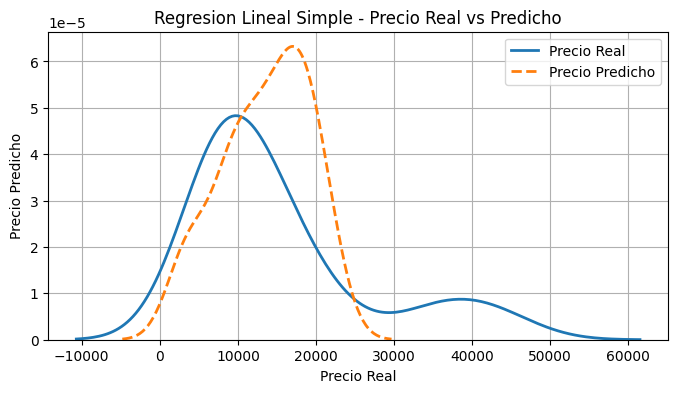

In [8]:
# 7. Comparar precios reales vs. predichos
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresion Lineal Simple - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

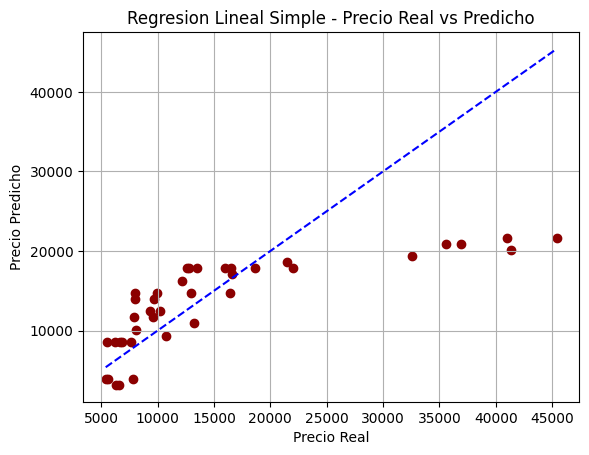

In [9]:
# Diagrama de Dipsersion
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresion Lineal Simple - Precio Real vs Predicho")
plt.grid(True)
plt.show()